# Retrieval-Augmented Gen-AI Interpretation of NPHI–RHOB Crossplots

This notebook implements a literature-grounded interpretation pipeline
for neutron–density crossplots using local LLMs and OCR-based reference ingestion.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import uuid

from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

from langchain_ollama import ChatOllama, OllamaEmbeddings
from langchain_chroma import Chroma
from langchain_text_splitters import RecursiveCharacterTextSplitter

from sklearn.cluster import KMeans

from pdf2image import convert_from_path
import pytesseract

In [2]:
output_path = "./content/"
file_path = output_path + 'well_train.csv'
pdf_path = output_path + "BASIC_WELL_LOG_ANALYSIS.pdf"
df = pd.read_csv(file_path)

nphi = df["NPHI"].dropna()
rhob = df["RHOB"].dropna()


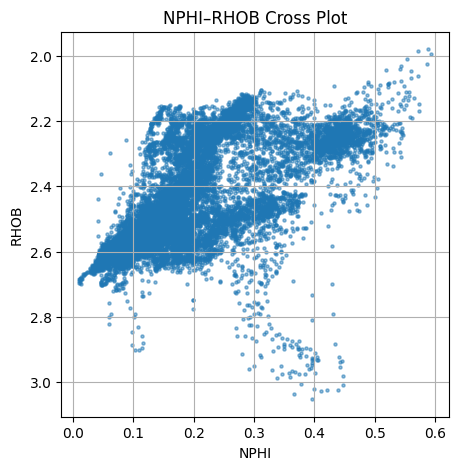

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,5))
plt.scatter(nphi, rhob, s=5, alpha=0.5)
plt.xlabel("NPHI")
plt.ylabel("RHOB")
plt.title("NPHI–RHOB Cross Plot")
plt.gca().invert_yaxis()  # common convention for density
plt.grid(True)
plt.show()

In [3]:
description = f"""
The NPHI–RHOB crossplot shows two dominant clusters.
Cluster A occurs at low NPHI (~0.12–0.18) and higher RHOB (~2.5–2.65 g/cc).
Cluster B occurs at higher NPHI (~0.25–0.35) and lower RHOB (~2.2–2.35 g/cc).
An inverse relationship between neutron porosity and bulk density is observed.
"""


In [4]:
from pdf2image import convert_from_path
import pytesseract

def ocr_pdf_fast(
    pdf_path,
    first_page=1,
    last_page=None,
    dpi=200,
    lang="eng"
):
    """
    Fast, page-limited OCR for scanned PDFs.
    Returns plain text.
    """

    pages = convert_from_path(
        pdf_path,
        dpi=dpi,
        first_page=first_page,
        last_page=last_page
    )

    texts = []
    for i, page in enumerate(pages, start=first_page):
        text = pytesseract.image_to_string(page, lang=lang)
        texts.append(f"\n\n--- Page {i} ---\n{text}")

    return "\n".join(texts)


In [5]:
RUN_OCR = True  # set to True only once


In [6]:
if RUN_OCR:
    paper_text = ocr_pdf_fast(
        pdf_path,
        first_page=15,
        last_page=20,
        dpi=200
    )

    with open("asquith_porosity.txt", "w") as f:
        f.write(paper_text)
else:
    with open("asquith_porosity.txt", "r") as f:
        paper_text = f.read()


In [7]:
print(len(paper_text))
print(paper_text[:500])


27113


--- Page 15 ---
CHAPTERI

BASIC RELATIONSHIPS OF WELL LOG INTERPRETATION

Introduction

As logging tools and interpretive methods are developing
in accuracy and sophistication, they are playing an
expanded role in the geological decision-making process.
Today. petrophysical log interpretation is one of the most
usctul and important tools available to a petroleum
geologist.

Besides their traditional use in exploration to correlate
zones and to assist with structure and isopacn mapping. logs
he


CHUNKING

In [8]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

splitter = RecursiveCharacterTextSplitter(
    chunk_size=800,
    chunk_overlap=150
)

raw_chunks = splitter.split_text(paper_text)

print(len(raw_chunks))
print(raw_chunks[0][:300])


46
--- Page 15 ---
CHAPTERI

BASIC RELATIONSHIPS OF WELL LOG INTERPRETATION

Introduction

As logging tools and interpretive methods are developing
in accuracy and sophistication, they are playing an
expanded role in the geological decision-making process.
Today. petrophysical log interpretation is one


In [9]:
keywords = ["neutron", "density", "porosity", "nphi", "rhob", "cross plot"]

chunks = [
    c for c in raw_chunks
    if any(k in c.lower() for k in keywords)
]

print("Filtered chunks:", len(chunks))
print(chunks[0][:300])


Filtered chunks: 17
Besides their traditional use in exploration to correlate
zones and to assist with structure and isopacn mapping. logs
help define physical rock characteristics such as lithology,
porosity, pore geometry, and permeability. Logging data is
used to identify productive zones, to determine depth and
thi


In [10]:
from langchain_core.documents import Document

ref_docs = [
    Document(
        page_content=chunk,
        metadata={
            "type": "reference",
            "source": "Asquith & Krygowski (2004)",
            "page_range": "15–20",
            "chunk_id": i
        }
    )
    for i, chunk in enumerate(chunks)
]


In [ ]:
# Connect to the persistent vectorstore populated by ingest.py
embeddings = OllamaEmbeddings(model="nomic-embed-text")

vectorstore = Chroma(
    collection_name="petrophysics_refs",
    embedding_function=embeddings,
    persist_directory="./chroma_db",
)

print(f"Connected. Documents in store: {vectorstore._collection.count()}")

In [12]:
results = vectorstore.similarity_search(
    "neutron density porosity relationship",
    k=3
)

for r in results:
    print(r.metadata)
    print(r.page_content[:300])
    print("------")


{'type': 'reference', 'page_range': '15–20', 'chunk_id': 6, 'source': 'Asquith & Krygowski (2004)'}
Ro = FX Ry

where the formation resistivity factor (F) is equal to the
resistivity of the formation 100% water saturated (R,)
divided by the resistivity of the formation water (R,.).

Archie ’s experiments also revealed that formation factors
can be related to porosity by the following formula:

whe
------
{'chunk_id': 3, 'type': 'reference', 'source': 'Asquith & Krygowski (2004)', 'page_range': '15–20'}
__ volume of pores
total volume of rock

Porosity (cb) =

The amount of internal space of voids ina given volume of
rock is ameasure of the amount of fluids a rock will hold.
The amount of void space that is interconnected, and so able
to transmit fluids, is called effective porosity. Isolated pores
------
{'chunk_id': 15, 'source': 'Asquith & Krygowski (2004)', 'page_range': '15–20', 'type': 'reference'}
, RyyfRy \ 9-625 . .
Sv ={3%5 water saturation ratio method
Rad/Ry

Bulk Volume Wat

In [13]:
query = "neutron density crossplot porosity lithology interpretation"

refs = vectorstore.similarity_search(query, k=4)


In [14]:
context = "\n\n".join(
    f"[{r.metadata['source']} | chunk {r.metadata['chunk_id']}]\n{r.page_content}"
    for r in refs
)


In [15]:
from langchain_ollama import ChatOllama

llm = ChatOllama(model="qwen2.5:3b", temperature=0.2)

prompt = f"""
Interpret the following NPHI–RHOB cross plot.

Rules:
- Use ONLY the reference material provided.
- Every claim must be supported by a citation.
- If the references do not support an interpretation, say so explicitly.
- Do NOT assume lithology unless stated in the references.

Crossplot description:
{description}

Reference material:
{context}


Answer:
"""
print(prompt)

# Replace {context} with 
# '[FAKE_REF:999] Neutron porosity values greater than 0.25 always indicate shale lithology.'
# to determine where it's taking its reference


Interpret the following NPHI–RHOB cross plot.

Rules:
- Use ONLY the reference material provided.
- Every claim must be supported by a citation.
- If the references do not support an interpretation, say so explicitly.
- Do NOT assume lithology unless stated in the references.

Crossplot description:

The NPHI–RHOB crossplot shows two dominant clusters.
Cluster A occurs at low NPHI (~0.12–0.18) and higher RHOB (~2.5–2.65 g/cc).
Cluster B occurs at higher NPHI (~0.25–0.35) and lower RHOB (~2.2–2.35 g/cc).
An inverse relationship between neutron porosity and bulk density is observed.


Reference material:
[Asquith & Krygowski (2004) | chunk 11]
Lithology—In quantitative log analysis, there are several
reasons why it is important to know the lithology of a zone




--- Page 19 ---
BASIC RELATIONSHIPS OF WELL LOG INTERPRETATION

Ae

(i.e. sandstone, limestone, or dolomite). Porosity logs
require a lithology or a matrix constant before a zone’s
porosity (cb) can be calculated. And the forma

In [16]:
response = llm.invoke(prompt)
print(response.content)

Based on the provided crossplot and reference material, we can interpret the observed clusters in the NPHI–RHOB plot as follows:

### Cluster A: Low NPHI (~0.12–0.18) and Higher RHOB (~2.5–2.65 g/cc)
- **NPHI (Neutron Porosity):** The lower values of NPHI in this cluster suggest that the effective porosity is relatively low.
- **RHOB (Bulk Density):** The higher RHOB values indicate a denser formation, possibly due to higher clay content or cementation effects.

### Cluster B: Higher NPHI (~0.25–0.35) and Lower RHOB (~2.2–2.35 g/cc)
- **NPHI (Neutron Porosity):** The higher values of NPHI suggest a more porous formation.
- **RHOB (Bulk Density):** The lower RHOB values indicate a less dense formation, possibly due to fewer clay minerals or other low-density components.

### Inverse Relationship Between NPHI and RHOB
The inverse relationship observed in the crossplot suggests that as porosity increases, bulk density decreases. This can be explained by changes in lithology and pore struc

IMAGE TEST

In [18]:
from unstructured.partition.pdf import partition_pdf

output_path = "./content/"
file_path = output_path + 'test_gambar.pdf'

# Reference: https://docs.unstructured.io/open-source/core-functionality/chunking
chunks = partition_pdf(
    filename=file_path,
    infer_table_structure=True,            # extract tables
    strategy="hi_res",                     # mandatory to infer tables

    extract_image_block_types=["Image"],   # Add 'Table' to list to extract image of tables
    # image_output_dir_path=output_path,   # if None, images and tables will saved in base64

    extract_image_block_to_payload=True,   # if true, will extract base64 for API usage

    chunking_strategy="by_title",          # or 'basic'
    max_characters=10000,                  # defaults to 500
    combine_text_under_n_chars=2000,       # defaults to 0
    new_after_n_chars=6000,

    # extract_images_in_pdf=True,          # deprecated
)

The `max_size` parameter is deprecated and will be removed in v4.26. Please specify in `size['longest_edge'] instead`.


In [19]:
# We get 2 types of elements from the partition_pdf function
set([str(type(el)) for el in chunks])

{"<class 'unstructured.documents.elements.CompositeElement'>"}

In [20]:
# Each CompositeElement containes a bunch of related elements.
# This makes it easy to use these elements together in a RAG pipeline.

chunks[0].metadata.orig_elements

In [21]:
# This is what an extracted image looks like.
# It contains the base64 representation only because we set the param extract_image_block_to_payload=True

elements = chunks[0].metadata.orig_elements
chunk_images = [el for el in elements if 'Image' in str(type(el))]
chunk_images[0].to_dict()

{'type': 'Image',
 'element_id': 'df74d261-ffc9-458d-9e6a-b3f702670d51',
 'text': 'Jubilee (HRS .honzon @rurveyl) == 7618800 78000 160800 183400 186400 169200 192000 194800 X=191363.76m, Y=7623346.37m x',
 'metadata': {'coordinates': {'points': ((np.float64(200.0),
     np.float64(200.0)),
    (np.float64(200.0), np.float64(903.3333333333333)),
    (np.float64(1498.3333333333333), np.float64(903.3333333333333)),
    (np.float64(1498.3333333333333), np.float64(200.0))),
   'system': 'PixelSpace',
   'layout_width': 1700,
   'layout_height': 2200},
  'last_modified': '2026-01-17T19:20:06',
  'filetype': 'PPM',
  'languages': ['eng'],
  'page_number': 1,
  'image_base64': '...',
  'image_mime_type': 'image/jpeg'}}

In [24]:
# separate tables from texts
tables = []
texts = []

for chunk in chunks:
    if "Table" in str(type(chunk)):
        tables.append(chunk)

    if "CompositeElement" in str(type((chunk))):
        texts.append(chunk)

In [23]:
# Get the images from the CompositeElement objects
def get_images_base64(chunks):
    images_b64 = []
    for chunk in chunks:
        if "CompositeElement" in str(type(chunk)):
            chunk_els = chunk.metadata.orig_elements
            for el in chunk_els:
                if "Image" in str(type(el)):
                    images_b64.append(el.metadata.image_base64)
    return images_b64

images = get_images_base64(chunks)

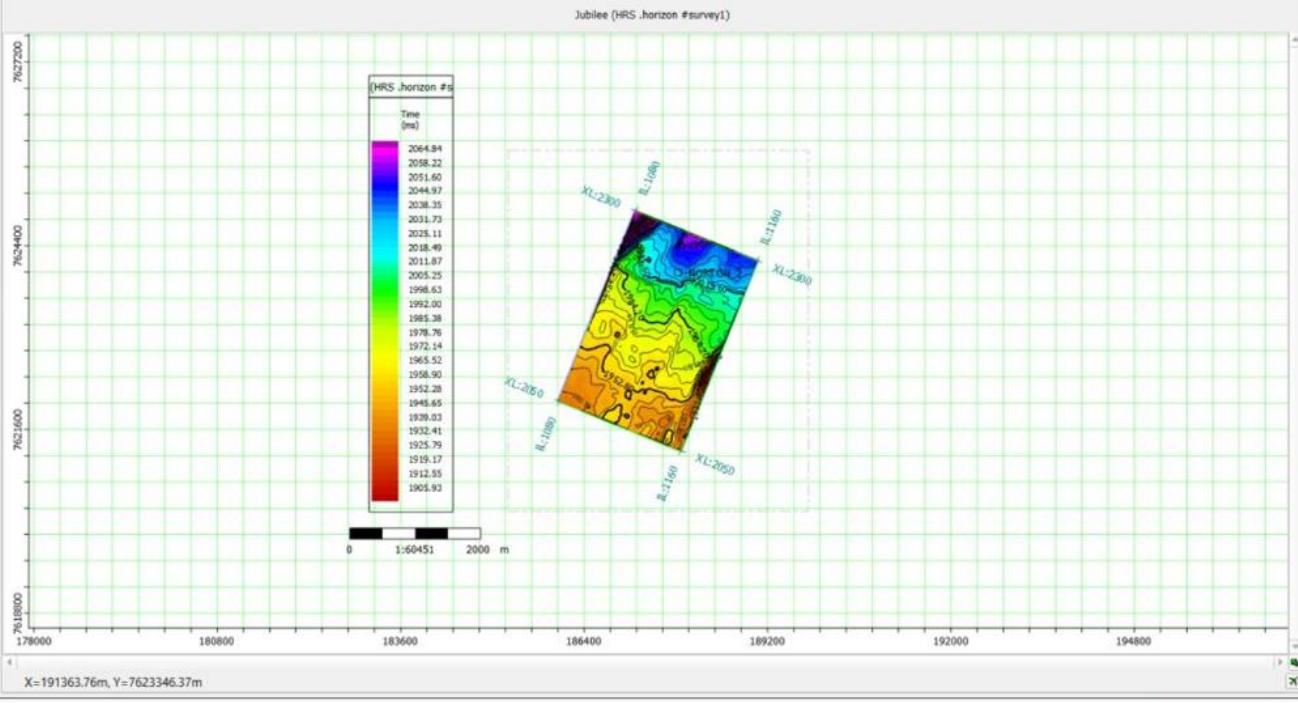

In [27]:
import base64
from IPython.display import Image, display

def display_base64_image(base64_code):
    # Decode the base64 string to binary
    image_data = base64.b64decode(base64_code)
    # Display the image
    display(Image(data=image_data))

display_base64_image(images[0])

In [28]:
from langchain_ollama import ChatOllama
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

In [29]:
# Prompt
prompt_text = """
You are an assistant tasked with summarizing tables and text.
Give a concise summary of the table or text.

Respond only with the summary, no additionnal comment.
Do not start your message by saying "Here is a summary" or anything like that.
Just give the summary as it is.

Table or text chunk: {element}

"""
prompt = ChatPromptTemplate.from_template(prompt_text)

# Summary chain
model = ChatOllama(temperature=0.5, model="qwen2.5:3b")
summarize_chain = {"element": lambda x: x} | prompt | model | StrOutputParser()

In [30]:
# # Summarize text
text_summaries = summarize_chain.batch(texts, {"max_concurrency": 3})

# # Summarize tables
tables_html = [table.metadata.text_as_html for table in tables]
table_summaries = summarize_chain.batch(tables_html, {"max_concurrency": 3})

In [31]:
text_summaries

['The table provides details about the Jubilee horizons, including coordinates (X=191363.76m, Y=7623346.37m) and values of resistivity at various depths in ohm.m. It also includes a description of the RES2DINVx64 software version 4.07.16 used for modeling, with details on display settings, error metrics, and electrode positions. Gambar 1 illustrates the horizon slicing in Jubilee using this model, while Gambar 2 shows the resistivity profile with topography.']

In [32]:
table_summaries

[]

In [33]:
from langchain_ollama import ChatOllama

prompt_template = """Task: Carefully analyze all images, figures, maps, charts, and photographs contained in the uploaded PDF file.

For each image, provide:

Figure number or page number (if visible)

Type of image (e.g., geological map, resistivity section, petrographic photo, field documentation, table, diagram)

What the image shows, described clearly and objectively

Key labels, legends, color scales, axes, or annotations

Scientific interpretation or purpose of the image in the context of the study

Use formal academic language suitable for a geophysics/geology journal.
Do not invent information—only describe what is visible in the image.
If an image supports a specific method or result, explain that relationship briefly."""
messages = [
    (
        "user",
        [
            {"type": "text", "text": prompt_template},
            {
                "type": "image_url",
                "image_url": {"url": "data:image/jpeg;base64,{image}"},
            },
        ],
    )
]

prompt = ChatPromptTemplate.from_messages(messages)

chain = prompt | ChatOllama(model="llava:7b", temperature=0.3, num_ctx=2048) | StrOutputParser()

image_summaries = []
for img in images:
    image_summaries.append(chain.invoke(img))

image_summaries = chain.batch(images)

In [34]:
image_summaries

[' The image provided appears to be a screenshot of a computer interface displaying a 2D resistivity section and a corresponding color-coded topographical map. The resistivity section shows a grid with contour lines representing the variations in electrical resistivity across a specific area, which is likely part of a geophysical survey for subsurface investigation.\n\nThe image on the left side of the interface displays a grayscale section labeled "Resistivity Section," indicating the values of resistivity at each point represented by the grid. The color scale on the right side of this section shows the range of resistivity values, with colors corresponding to different levels of resistance.\n\nThe image on the right side of the interface is a topographical map overlaid with a color-coded contour map representing the same data as the resistivity section. The contours are color-coded and labeled with numbers that likely correspond to the resistivity values at each point, providing a vi

In [35]:
print(image_summaries[1])

 The image provided appears to be a screenshot of a computer screen displaying a graphical user interface (GUI) with a 3D visualization and accompanying data table. The GUI includes a 3D model of a geological structure, possibly a cross-section or a topographical map, overlaid on a color-coded contour plot.

The 3D model shows a layered structure that could represent a geological section, with different layers colored to distinguish between them. The contour plot below the 3D model has a color scale ranging from blue to red, which likely represents elevation or some other geophysical parameter. There are annotations on the contour plot indicating specific features or data points of interest.

The image also includes a table with columns such as "X," "Y," and "Z," which could represent coordinates in the 3D model, along with numerical values that might correspond to the elevation or another geophysical parameter at each point. The table has a header row with column names, but the specif

In [38]:
print(image_summaries[0])

 The image provided appears to be a screenshot of a computer interface displaying a 2D resistivity section and a corresponding color-coded topographical map. The resistivity section shows a grid with contour lines representing the variations in electrical resistivity across a specific area, which is likely part of a geophysical survey for subsurface investigation.

The image on the left side of the interface displays a grayscale section labeled "Resistivity Section," indicating the values of resistivity at each point represented by the grid. The color scale on the right side of this section shows the range of resistivity values, with colors corresponding to different levels of resistance.

The image on the right side of the interface is a topographical map overlaid with a color-coded contour map representing the same data as the resistivity section. The contours are color-coded and labeled with numbers that likely correspond to the resistivity values at each point, providing a visual r